# EDA — Amazon Books Reviews
Desafio Técnico A3Data — Cientista de Dados (LLM/NLP)

Análise exploratória da amostra de reviews (`data/processed/sample_reviews.parquet`,
~199k reviews, amostra proporcional por nota do dataset original de ~3M reviews),
cruzada com metadados de livros (autor, gênero, editora).

Objetivo: entender performance por autor/gênero, e levantar hipóteses de negócio
para orientar a ferramenta de análise automatizada proposta à editora.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src import viz_style

viz_style.apply()
C = viz_style.CATEGORICAL

df = pd.read_parquet("../data/processed/sample_reviews.parquet")
df.shape

(198924, 19)

## Visão geral

In [2]:
print(f"Reviews na amostra: {len(df):,}")
print(f"Livros únicos: {df['Title'].nunique():,}")
print(f"Autores únicos: {df['primary_author'].nunique():,}")
print(f"Gêneros únicos: {df['primary_category'].nunique():,}")
print(f"Período: {int(df['review_year'].min())}–{int(df['review_year'].max())}")
df[["score", "review_len", "ratingsCount", "price"]].describe()

Reviews na amostra: 198,924
Livros únicos: 61,940
Autores únicos: 38,187
Gêneros únicos: 3,842
Período: 1995–2013


,score,review_len,ratingsCount,price
count,198924.000000,198924.000000,108523.000000,32030.000000
mean,4.215856,826.731033,267.838891,21.772099
std,1.203850,979.379215,782.844838,26.369997
min,1.000000,1.000000,1.000000,1.000000
25%,4.000000,261.000000,3.000000,10.740000
50%,5.000000,517.000000,10.000000,14.930000
75%,5.000000,1013.000000,54.000000,23.900000
max,5.000000,32291.000000,4562.000000,795.000000


## Distribuição de notas (score)

O dataset original já é enviesado para notas altas (~60% de 5 estrelas) — a amostra
preserva essa proporção de propósito, para refletir o cenário real que a editora vê.

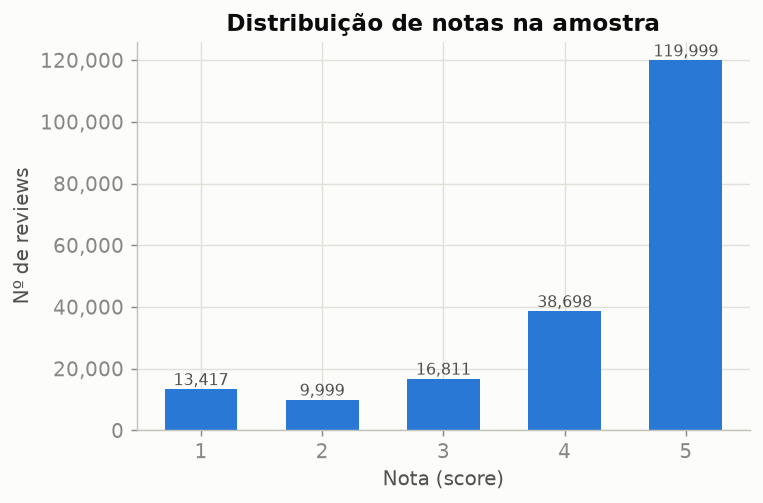

In [3]:
score_counts = df["score"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(score_counts.index.astype(int).astype(str), score_counts.values, color=C[0], width=0.6)
ax.set_title("Distribuição de notas na amostra")
ax.set_xlabel("Nota (score)")
ax.set_ylabel("Nº de reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for b in bars:
    ax.annotate(f"{b.get_height():,.0f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=9, color=viz_style.INK_SECONDARY)
fig.tight_layout()
fig.savefig("../outputs/figures/score_distribution.png")
plt.show()

## Volume de reviews ao longo do tempo

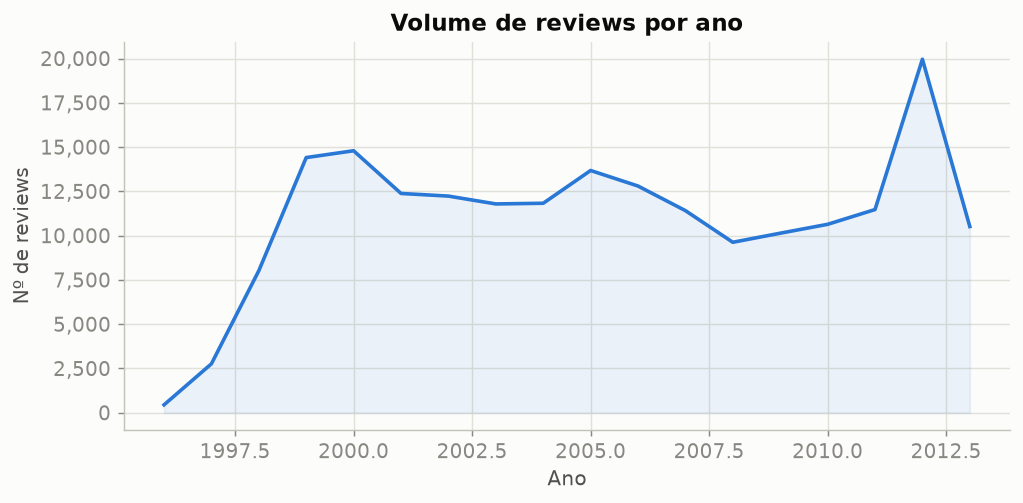

In [4]:
year_counts = df.groupby("review_year").size()
year_counts = year_counts[year_counts.index >= 1996]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(year_counts.index, year_counts.values, color=C[0], linewidth=2)
ax.fill_between(year_counts.index, year_counts.values, color=C[0], alpha=0.08)
ax.set_title("Volume de reviews por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Nº de reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.tight_layout()
fig.savefig("../outputs/figures/reviews_por_ano.png")
plt.show()

## Gêneros mais avaliados e melhor avaliados

Para "melhor avaliado" uso apenas gêneros com volume mínimo de reviews, para não deixar
um gênero com 3 reviews de nota 5 aparecer como o "melhor".

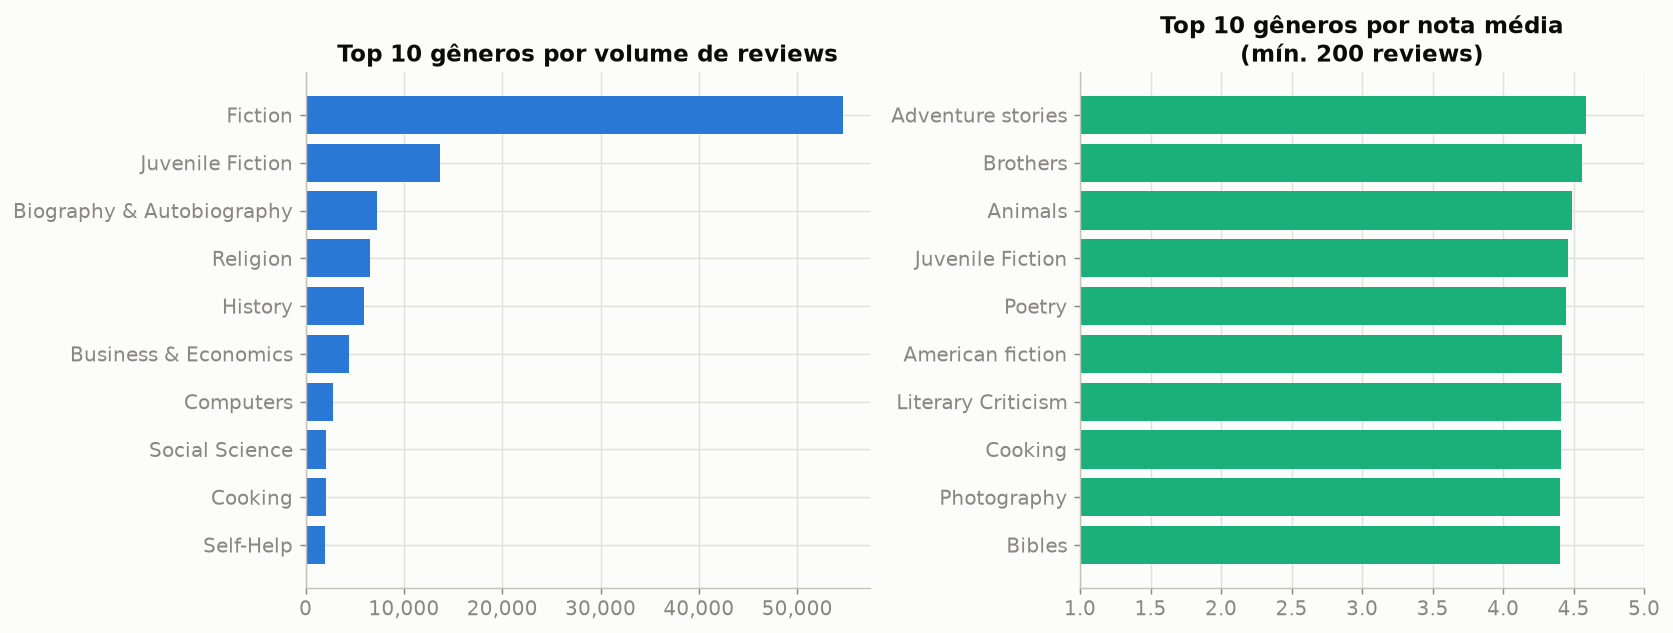

In [5]:
MIN_REVIEWS_GENRE = 200

genre_stats = (
    df.dropna(subset=["primary_category"])
    .groupby("primary_category")["score"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_reviews", "mean": "avg_score"})
)

top_volume = genre_stats.sort_values("n_reviews", ascending=False).head(10)
top_rated = genre_stats[genre_stats["n_reviews"] >= MIN_REVIEWS_GENRE].sort_values("avg_score", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(top_volume.index[::-1], top_volume["n_reviews"][::-1], color=C[0])
axes[0].set_title("Top 10 gêneros por volume de reviews")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].barh(top_rated.index[::-1], top_rated["avg_score"][::-1], color=C[1])
axes[1].set_title(f"Top 10 gêneros por nota média\n(mín. {MIN_REVIEWS_GENRE} reviews)")
axes[1].set_xlim(1, 5)

fig.tight_layout()
fig.savefig("../outputs/figures/generos_volume_nota.png")
plt.show()

## Autores mais avaliados e melhor avaliados

Mesma lógica: nota média só entre autores com volume mínimo de reviews.

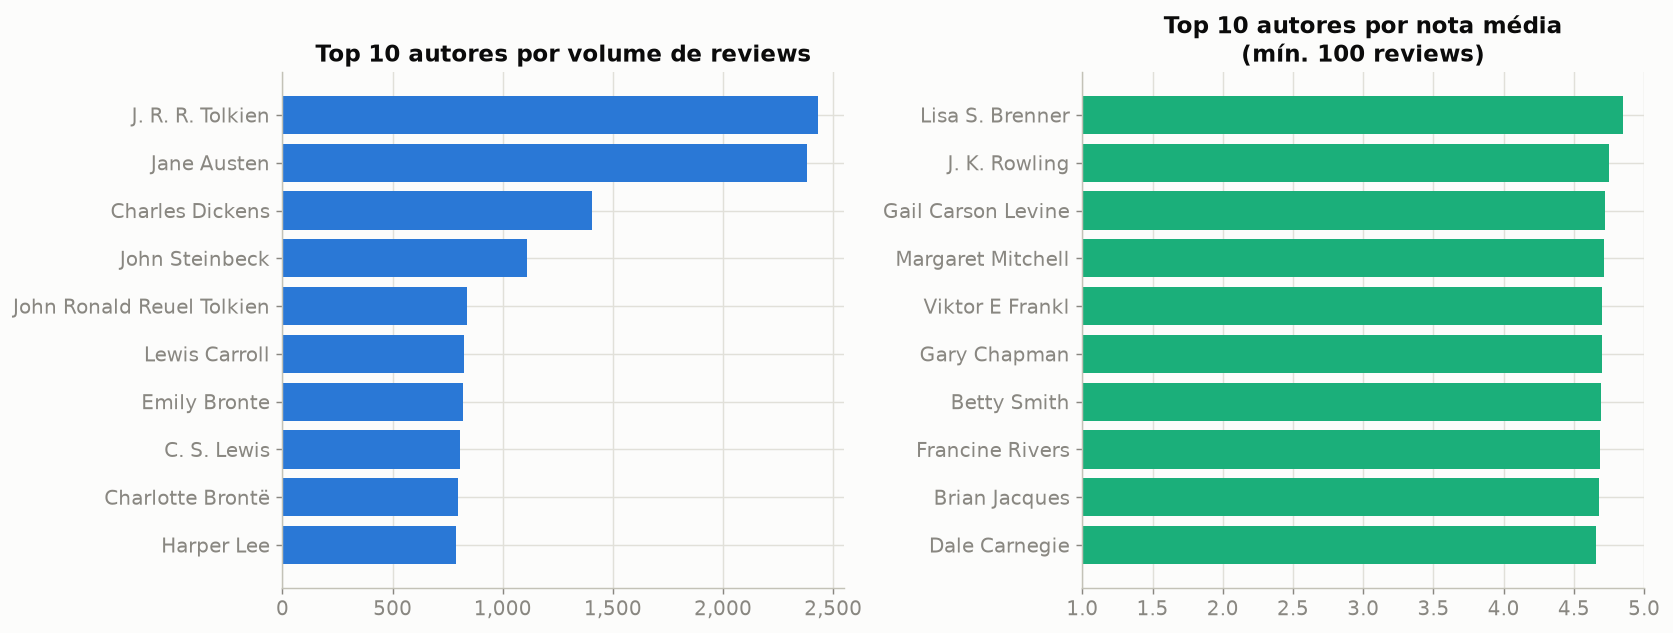

In [6]:
MIN_REVIEWS_AUTHOR = 100

author_stats = (
    df.dropna(subset=["primary_author"])
    .groupby("primary_author")["score"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_reviews", "mean": "avg_score"})
)

top_volume_a = author_stats.sort_values("n_reviews", ascending=False).head(10)
top_rated_a = author_stats[author_stats["n_reviews"] >= MIN_REVIEWS_AUTHOR].sort_values("avg_score", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(top_volume_a.index[::-1], top_volume_a["n_reviews"][::-1], color=C[0])
axes[0].set_title("Top 10 autores por volume de reviews")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].barh(top_rated_a.index[::-1], top_rated_a["avg_score"][::-1], color=C[1])
axes[1].set_title(f"Top 10 autores por nota média\n(mín. {MIN_REVIEWS_AUTHOR} reviews)")
axes[1].set_xlim(1, 5)

fig.tight_layout()
fig.savefig("../outputs/figures/autores_volume_nota.png")
plt.show()

## Tamanho das reviews vs. nota

Reviews mais longas tendem a ser mais detalhadas — vale olhar se há relação com a nota
dada (hipótese: reviews muito negativas ou muito positivas tendem a ser mais longas que
notas neutras).

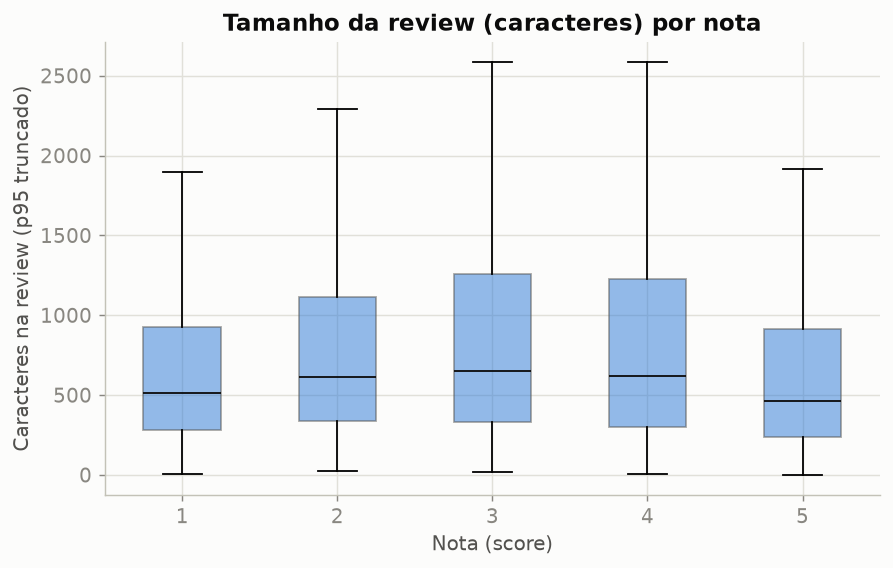

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data_by_score = [df.loc[df["score"] == s, "review_len"].clip(upper=df["review_len"].quantile(0.95)) for s in sorted(df["score"].unique())]
bp = ax.boxplot(data_by_score, tick_labels=[str(int(s)) for s in sorted(df["score"].unique())],
                 patch_artist=True, showfliers=False, widths=0.5)
for patch in bp["boxes"]:
    patch.set_facecolor(C[0])
    patch.set_alpha(0.5)
    patch.set_edgecolor(viz_style.INK_SECONDARY)
for median in bp["medians"]:
    median.set_color(viz_style.INK_PRIMARY)
ax.set_title("Tamanho da review (caracteres) por nota")
ax.set_xlabel("Nota (score)")
ax.set_ylabel("Caracteres na review (p95 truncado)")
fig.tight_layout()
fig.savefig("../outputs/figures/tamanho_review_por_nota.png")
plt.show()

## Cobertura de metadados (autor/gênero)

In [8]:
coverage = df["primary_author"].notna().mean()
print(f"% de reviews com autor identificado: {coverage:.1%}")
coverage_genre = df["primary_category"].notna().mean()
print(f"% de reviews com gênero identificado: {coverage_genre:.1%}")

% de reviews com autor identificado: 87.1%
% de reviews com gênero identificado: 81.6%


## Principais achados (preliminares)

- **Base fortemente enviesada para notas altas**: 60% das reviews são 5 estrelas
  (119.999 / 198.924) e 80% são 4 ou 5 estrelas — típico de reviews de e-commerce.
  Isso reforça a importância de olhar o *texto*, não só a nota, para captar nuances
  (uma nota 4 pode esconder uma crítica relevante).
- **Cobertura de metadados**: 87,1% das reviews casam com autor identificado e 81,6%
  com gênero — suficiente para análises por autor/gênero, mas ~13-19% ficam de fora
  (títulos ausentes de `books_data.csv`), relevante para o roadmap de qualidade de dados.
- **Qualidade de dados — nomes de autor duplicados**: "J. R. R. Tolkien" e "John Ronald
  Reuel Tolkien" aparecem como autores **separados** no ranking de volume, quando são a
  mesma pessoa. Isso é uma evidência direta de que o processo manual atual provavelmente
  já sofre com esse problema — e é um caso de uso natural para **normalização de
  entidades via LLM** (uma das propostas de valor da ferramenta).
- **Tamanho da review por nota**: reviews de nota 3-4 tendem a ser as mais longas
  (mediana ~600-650 caracteres) — o leitor "no meio do caminho" costuma explicar o
  porquê. Reviews 5 estrelas são as mais curtas (mediana ~470 caracteres) — elogio
  rápido, pouco detalhe. Isso é um sinal de que **notas extremas nem sempre têm o
  review mais informativo** — outro argumento para a heurística de "reviewer relevante"
  não se basear só na nota.
- **Volume ao longo do tempo**: crescimento forte de reviews até ~2000, um segundo pico
  em 2012 (quase 20 mil reviews no ano) — a queda em 2013 é efeito de corte parcial do
  ano na coleta dos dados, não uma queda real de volume.
- **Gêneros dominantes**: Fiction domina em volume (mais de 50 mil reviews, muito à
  frente do 2º colocado); gêneros de nicho (Poetry, Photography, Bibles) aparecem entre
  os mais bem avaliados, mas com volume baixo — validam a regra de nota mínima de
  reviews para evitar ranking enganoso.
